# Arquitectura MLP

In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Usando device: {device}")

X_train = np.load('data/X_train_processed.npy')
X_val = np.load('data/X_val_processed.npy')
y_train = np.load('data/y_train.npy') 
y_val = np.load('data/y_val.npy')

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

Usando device: cpu
X_train: (934, 223), X_val: (234, 223)


## Estrategia de división d edatos y validación cruzada

In [4]:
from sklearn.model_selection import train_test_split
import pandas as pd

print("Tamaño de validación:", X_val.shape[0], f"({X_val.shape[0]/(X_train.shape[0]+X_val.shape[0])*100:.1f}% del total)")

Tamaño de validación: 234 (20.0% del total)


## Arquitecturas de red consideradas

In [5]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout=0.0, batch_norm=False):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


ARCHITECTURES = {
    'shallow':  [64],
    'medium':   [128, 64],
    'deep':     [256, 128, 64, 32],
}

for name, layers in ARCHITECTURES.items():
    m = MLP(X_train.shape[1], layers)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:10s} {str(layers):20s} -> {n_params:,} parámetros")

shallow    [64]                 -> 14,401 parámetros
medium     [128, 64]            -> 36,993 parámetros
deep       [256, 128, 64, 32]   -> 100,609 parámetros


## Hiperparámetros

In [6]:
HYPERPARAMS = {
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'batch_size': 32,
    'max_epochs': 200,
    'patience': 15,      
    'dropout': 0.2,
    'batch_norm': True,
}
HYPERPARAMS

{'lr': 0.001,
 'weight_decay': 0.0001,
 'batch_size': 32,
 'max_epochs': 200,
 'patience': 15,
 'dropout': 0.2,
 'batch_norm': True}

## Técnicas de regularización

In [7]:
def train_model(hidden_layers, hp, X_train, y_train, X_val, y_val, verbose=True):
    model = MLP(X_train.shape[1], hidden_layers,
                dropout=hp['dropout'], batch_norm=hp['batch_norm']).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=hp['lr'], weight_decay=hp['weight_decay'])
    loss_fn = nn.MSELoss()

    Xtr_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    ytr_t = torch.tensor(y_train, dtype=torch.float32).to(device)
    Xva_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    yva_t = torch.tensor(y_val, dtype=torch.float32).to(device)

    train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=hp['batch_size'], shuffle=True)

    history = {'train_rmse': [], 'val_rmse': []}
    best_val_rmse = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(hp['max_epochs']):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            train_rmse = torch.sqrt(loss_fn(model(Xtr_t), ytr_t)).item()
            val_rmse = torch.sqrt(loss_fn(model(Xva_t), yva_t)).item()
        history['train_rmse'].append(train_rmse)
        history['val_rmse'].append(val_rmse)

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and epoch % 20 == 0:
            print(f"  epoch {epoch:3d}  train_rmse(log)={train_rmse:.4f}  val_rmse(log)={val_rmse:.4f}")

        if epochs_no_improve >= hp['patience']:
            if verbose:
                print(f"  Early stopping en epoch {epoch} (mejor val_rmse={best_val_rmse:.4f})")
            break

    model.load_state_dict(best_state)
    return model, history, best_val_rmse

# Entrenamiento de los modelos

In [8]:
results = {}
for name, layers in ARCHITECTURES.items():
    print(f"\nEntrenando arquitectura '{name}' {layers}...")
    model, history, best_val_rmse = train_model(layers, HYPERPARAMS, X_train, y_train, X_val, y_val)
    results[name] = {'model': model, 'history': history, 'best_val_rmse': best_val_rmse}
    print(f"  -> Mejor val_rmse (log): {best_val_rmse:.4f}")


Entrenando arquitectura 'shallow' [64]...
  epoch   0  train_rmse(log)=11.2906  val_rmse(log)=11.3031
  epoch  20  train_rmse(log)=0.5718  val_rmse(log)=1.1718
  Early stopping en epoch 37 (mejor val_rmse=1.0631)
  -> Mejor val_rmse (log): 1.0631

Entrenando arquitectura 'medium' [128, 64]...
  epoch   0  train_rmse(log)=11.5910  val_rmse(log)=11.5823
  epoch  20  train_rmse(log)=0.7540  val_rmse(log)=0.9128
  epoch  40  train_rmse(log)=0.6367  val_rmse(log)=0.7575
  Early stopping en epoch 53 (mejor val_rmse=0.5788)
  -> Mejor val_rmse (log): 0.5788

Entrenando arquitectura 'deep' [256, 128, 64, 32]...
  epoch   0  train_rmse(log)=11.7582  val_rmse(log)=11.7525
  epoch  20  train_rmse(log)=0.7174  val_rmse(log)=0.7541
  epoch  40  train_rmse(log)=0.5658  val_rmse(log)=0.5523
  epoch  60  train_rmse(log)=0.3954  val_rmse(log)=0.4088
  Early stopping en epoch 72 (mejor val_rmse=0.3652)
  -> Mejor val_rmse (log): 0.3652


## Curvas de entrenamiento

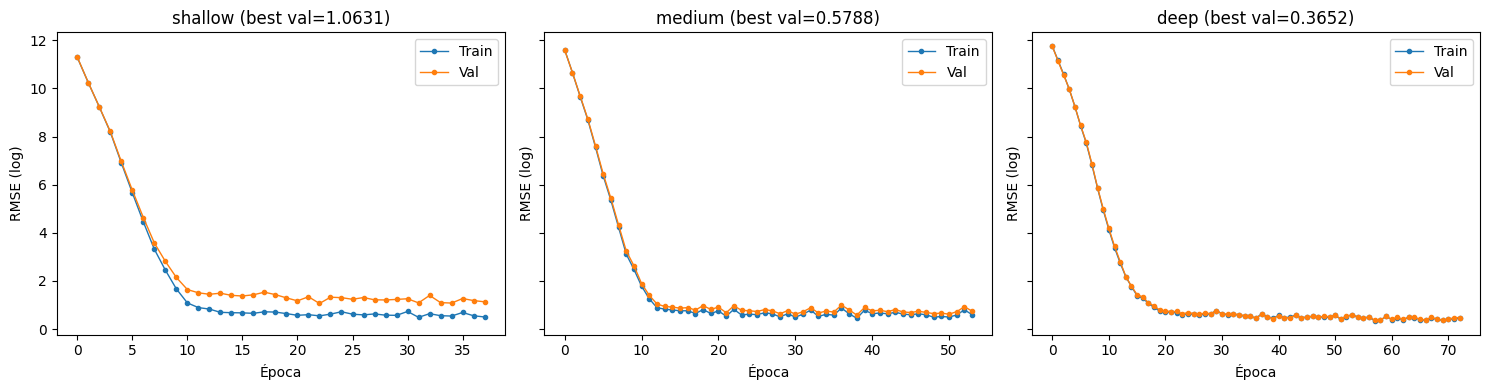

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, r) in zip(axes, results.items()):
    h = r['history']
    epochs = range(len(h['train_rmse']))
    ax.plot(epochs, h['train_rmse'], marker='o', markersize=3, linewidth=1, label='Train')
    ax.plot(epochs, h['val_rmse'], marker='o', markersize=3, linewidth=1, label='Val')
    ax.set_title(f"{name} (best val={r['best_val_rmse']:.4f})")
    ax.set_xlabel('Época')
    ax.set_ylabel('RMSE (log)')
    ax.legend()
plt.tight_layout()
plt.savefig('reports/arquitecturas_curvas.png', dpi=110)
plt.show()